4. Overfitting Experiement

In our model selection notebook I came to the conclusion that our CNN is the best choice. However in order to see if our model is not just doing well on the training data, because it rather memorize it instead of checking for general patterns. I'll coduct some tests in this notebook and see if the model is overfitting.

In this notebook we will try this techniques in order to test overfitting:
1. Dropout
2. Batch Normalization
3. L2 Regularization

In [9]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data.dataset import Dataset
from models.cnn_builder import CNNBuilder
from evaluation.evaluation_metrics import EvaluationMetrics
from models.training_callbacks import default_callbacks
from data.rarity_classes import RARITY_CLASSES
from evaluation.multi_run_eval import multi_run_evaluation

In [2]:
dataset = Dataset()
X_train, X_val, X_test, y_train, y_val, y_test = dataset.get_train_val_test_split()

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Input shape: {X_train.shape[1:]}")
print(f"Number of classes: {y_train.shape[1]}")

Training set: 1750 samples
Validation set: 375 samples
Test set: 375 samples
Input shape: (168, 120, 3)
Number of classes: 5


4.1 Helper Function

This helper function trains the model with early stopping and returns both the trained model and its training history.

In [3]:
def train_and_plot(builder, name, epochs=30):
    model = builder.build_model()
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=default_callbacks(),
        verbose=0
    )
    print(f"{name}: val_loss={history.history['val_loss'][-1]}, val_acc={history.history['val_accuracy'][-1]}")
    return model, history

4.2 Experiments

In this section we will conduct the experiments to test for overfitting. We will start with a simple CNN and then add dropout, batch normalization and L2 regularization to see how it affects the performance.


In [ ]:
histories = {}
models = {}

# 1. Baseline
builder = CNNBuilder(
    in_shape=(168, 120, 3),
    out_shape=5,
    convolutional_layers=[32, 64],
    fully_connected_layers=[128]
)
models['Baseline'], histories['Baseline'] = train_and_plot(builder, 'Baseline')

# 2. Dropout
builder = CNNBuilder(
    in_shape=(168, 120, 3),
    out_shape=5,
    convolutional_layers=[32, 64],
    fully_connected_layers=[128]
)
builder.apply_dropout = True
models['Dropout'], histories['Dropout'] = train_and_plot(builder, 'Dropout')

# 3. Batch Normalization
builder = CNNBuilder(
    in_shape=(168, 120, 3),
    out_shape=5,
    convolutional_layers=[32, 64],
    fully_connected_layers=[128]
)
builder.apply_batch_normalization = True
models['BatchNorm'], histories['BatchNorm'] = train_and_plot(builder, 'BatchNorm')

# 4. L2 Regularization
builder = CNNBuilder(
    in_shape=(168, 120, 3),
    out_shape=5,
    convolutional_layers=[32, 64],
    fully_connected_layers=[128]
)
builder.apply_regularization = True
models['L2'], histories['L2'] = train_and_plot(builder, 'L2')

# 5. All combined
builder = CNNBuilder(
    in_shape=(168, 120, 3),
    out_shape=5,
    convolutional_layers=[32, 64],
    fully_connected_layers=[128]
)
builder.apply_dropout = True
builder.apply_batch_normalization = True
builder.apply_regularization = True
models['All Combined'], histories['All Combined'] = train_and_plot(builder, 'All Combined')

2026-04-30 17:23:07.084658: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-04-30 17:23:07.084728: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-30 17:23:07.084740: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-30 17:23:07.085006: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-30 17:23:07.085373: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-30 17:23:09.359505: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Baseline: val_loss=1.2215081453323364, val_acc=0.7360000014305115
Dropout: val_loss=1.09909987449646, val_acc=0.6986666917800903
BatchNorm: val_loss=2.684986114501953, val_acc=0.20266667008399963
L2: val_loss=1.1331080198287964, val_acc=0.7360000014305115
All Combined: val_loss=2.8797900676727295, val_acc=0.20000000298023224


In [11]:
#here 
def make_baseline():                                                                                                                                           
    b = CNNBuilder(in_shape=(168, 120, 3), out_shape=5,
                    convolutional_layers=[32, 64], fully_connected_layers=[128])                                                                                
    return b.build_model()                                                                                                                                     
                                        
def make_dropout():                                                                                                                                            
    b = CNNBuilder(in_shape=(168, 120, 3), out_shape=5,                                                                                                        
                    convolutional_layers=[32, 64], fully_connected_layers=[128])                                                                                
    b.apply_dropout = True                                                                                                                                     
    return b.build_model()
                                                                                                                                                                
def make_batchnorm():                   
    b = CNNBuilder(in_shape=(168, 120, 3), out_shape=5,                                                                                                        
                    convolutional_layers=[32, 64], fully_connected_layers=[128])                                                                                
    b.apply_batch_normalization = True      
    return b.build_model()                                                                                                                                     
                
def make_l2():                                                                                                                                                 
    b = CNNBuilder(in_shape=(168, 120, 3), out_shape=5,
                    convolutional_layers=[32, 64], fully_connected_layers=[128])                                                                                
    b.apply_regularization = True       
    return b.build_model()                  
                                                                                                                                                                         
configs = [                                                                                                                                                    
    ("Baseline",     make_baseline),                                                                                                                           
    ("Dropout",      make_dropout),
    ("BatchNorm",    make_batchnorm),                                                                                                                          
    ("L2",           make_l2),          
]                                                                                                                                                              

summaries = []                                                                                                                                                 
for name, factory in configs:           
    print(f"\n=== {name} ===")
    summary, _ = multi_run_evaluation(                                                                                                                         
        factory,                            
        X_train, y_train, X_val, y_val, X_test, y_test,                                                                                                        
        num_runs=3,
        epochs=30,                                                                                                                                             
        description=name,                   
    )                                                                                                                                                          
    summaries.append(summary)
                                                                                                                                                                                
                                                                                                                                                                



=== Baseline ===
  Baseline run 1/3... acc=0.6773333333333333, f1=0.6698304340079704
  Baseline run 2/3... acc=0.712, f1=0.7059311387433331
  Baseline run 3/3... acc=0.6826666666666666, f1=0.6796130687746917

Baseline: acc=69.06666666666666% ± 1.5241269510650872%, f1=0.6851248805086652 ± 0.015244677148446172

=== Dropout ===
  Dropout run 1/3... acc=0.6853333333333333, f1=0.6828026200491648
  Dropout run 2/3... acc=0.6613333333333333, f1=0.6610388251920032
  Dropout run 3/3... acc=0.6746666666666666, f1=0.6752461872597728

Dropout: acc=67.37777777777777% ± 0.981809868194424%, f1=0.673029210833647 ± 0.009022266160326243

=== BatchNorm ===
  BatchNorm run 1/3... acc=0.2, f1=0.06666666666666667
  BatchNorm run 2/3... acc=0.2, f1=0.06666666666666667
  BatchNorm run 3/3... acc=0.36533333333333334, f1=0.25988022403911754

BatchNorm: acc=25.511111111111113% ± 7.79388807707839%, f1=0.13107118579081697 ± 0.09108174442349072

=== L2 ===
  L2 run 1/3... acc=0.72, f1=0.7188363140862056
  L2 run 2

In [12]:

                                                                                                                                                                
df = pd.DataFrame([{
    "Config": s["name"],                                                                                                                                       
    "Acc Mean": f"{s['accuracy_mean']*100:.1f}%",
    "Acc Std":  f"{s['accuracy_std']*100:.1f}%",
    "F1 Mean":  f"{s['f1_mean']:.3f}",  
    "F1 Std":   f"{s['f1_std']:.3f}",                                                                                                                          
    "Acc Min":  f"{s['accuracy_min']*100:.1f}%",                                                                                                               
    "Acc Max":  f"{s['accuracy_max']*100:.1f}%",                                                                                                               
} for s in summaries])                                                                                                                                         
                                            
print(df.to_string(index=False))

   Config Acc Mean Acc Std F1 Mean F1 Std Acc Min Acc Max
 Baseline    69.1%    1.5%   0.685  0.015   67.7%   71.2%
  Dropout    67.4%    1.0%   0.673  0.009   66.1%   68.5%
BatchNorm    25.5%    7.8%   0.131  0.091   20.0%   36.5%
       L2    70.0%    1.5%   0.694  0.020   68.3%   72.0%


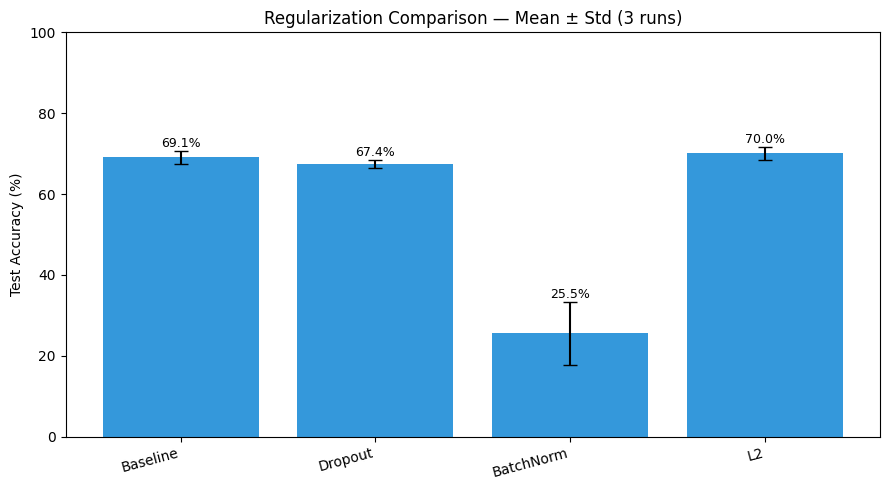

In [13]:
names = [s["name"] for s in summaries]      
means = [s["accuracy_mean"] * 100 for s in summaries]
stds = [s["accuracy_std"] * 100 for s in summaries]
                                                                                                                                                                
x = np.arange(len(names))               
plt.figure(figsize=(9, 5))                                                                                                                                     
plt.bar(x, means, yerr=stds, capsize=5, color="#3498db")                                                                                                       
plt.xticks(x, names, rotation=15, ha="right")
plt.ylabel("Test Accuracy (%)")                                                                                                                                
plt.title("Regularization Comparison — Mean ± Std (3 runs)")
plt.ylim(0, 100)                                                                                                                                               
for i, (m, s) in enumerate(zip(means, stds)):
    plt.text(i, m + s + 1, f"{m:.1f}%", ha="center", fontsize=9)                                                                                               
plt.tight_layout()                                                                                                                                             
plt.show()  

4.3 Visualize Training vx Validation Loss

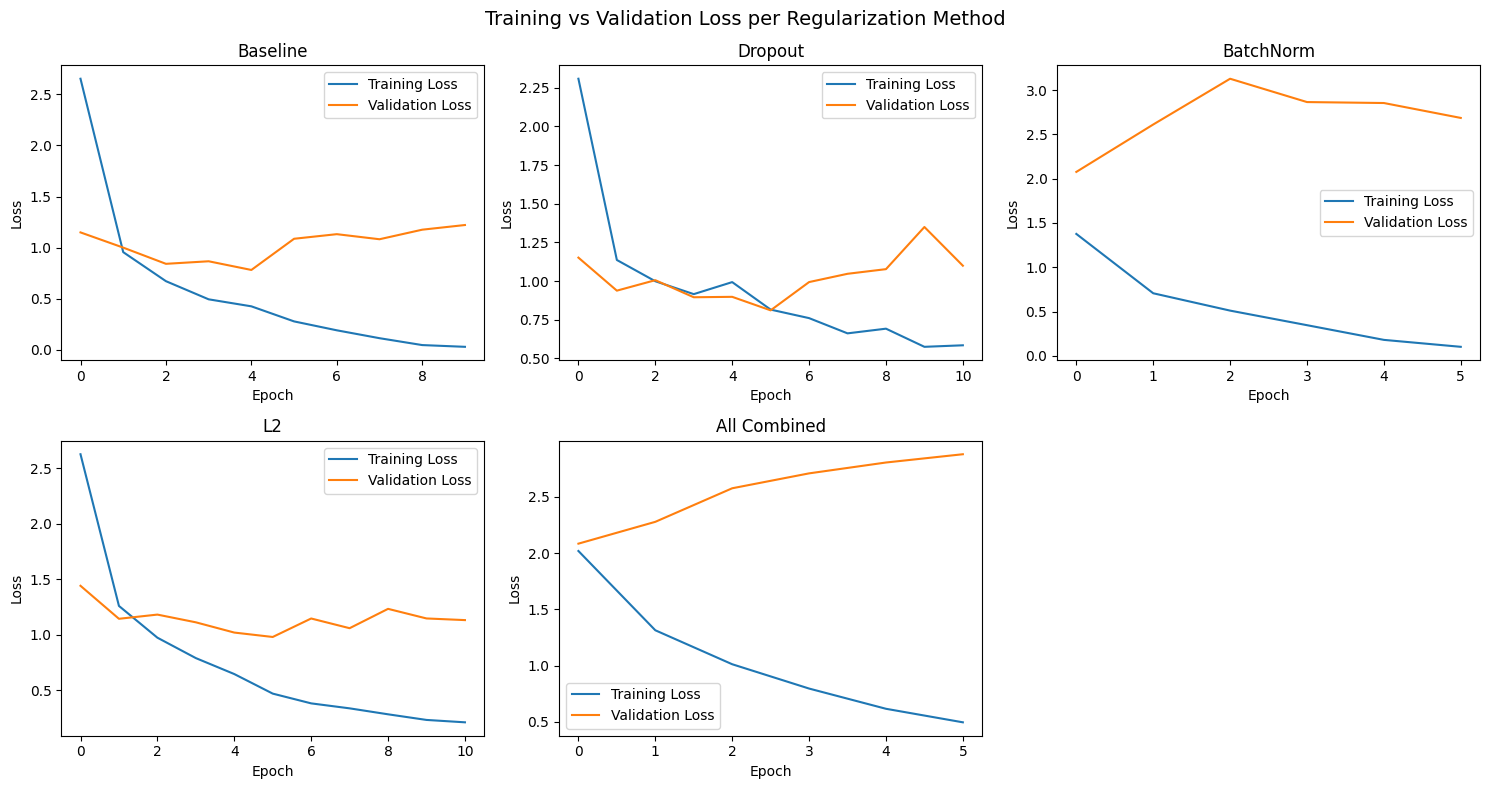

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (name, history) in enumerate(histories.items()):
    axes[i].plot(history.history['loss'], label='Training Loss')
    axes[i].plot(history.history['val_loss'], label='Validation Loss')
    axes[i].set_title(name)
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].legend()

# Hide the 6th subplot
axes[5].set_visible(False)

plt.suptitle('Training vs Validation Loss per Regularization Method', fontsize=14)
plt.tight_layout()
plt.show()

Outdated
From these plots we can see that our model is overfitting. The training loss gets smaller after each epoch and the validation loss gets bigger. This gap is an indication, that the model is rather memorizing the dataset instead of recognizing patterns. The dropout technique didn't had a big impact, also the L2 technique is still overfitting, but it is slighlty more stable than the dropout. For the batch normalization and all combined approach the graphs have both huge spikes on the validation loss, which indicates insability issues. 

4.4 Comparison Validation Accuracy

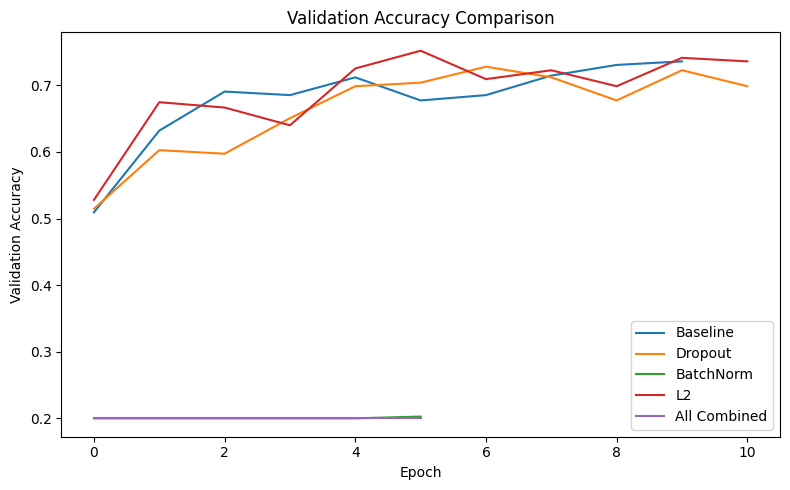

In [6]:
plt.figure(figsize=(8, 5))
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

4.5 Evaluation of the best config


Best configuration by val_loss: Baseline
Accuracy: 0.7173333333333334
F1 Score (Macro): 0.7123143514135131
              precision    recall  f1-score   support

      Common       0.64      0.75      0.69        75
    Uncommon       0.71      0.45      0.55        75
        Rare       0.60      0.71      0.65        75
  Ultra Rare       0.88      0.92      0.90        75
 Secret Rare       0.77      0.76      0.77        75

    accuracy                           0.72       375
   macro avg       0.72      0.72      0.71       375
weighted avg       0.72      0.72      0.71       375



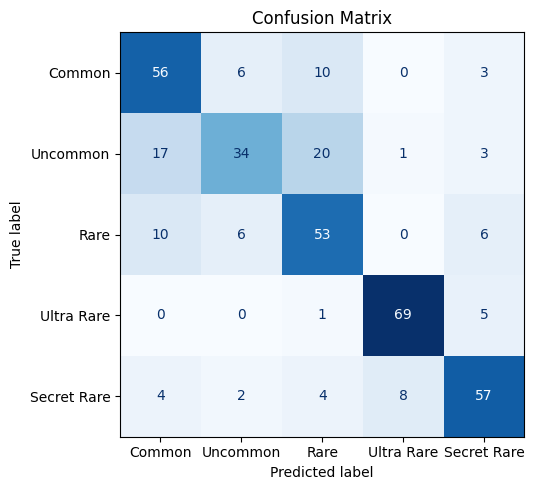

In [7]:
best_name = min(
    histories,
    key=lambda n: min(histories[n].history['val_loss']),
)
print(f"Best configuration by val_loss: {best_name}")

best_model = models[best_name]
y_pred_test = best_model.predict(X_test, verbose=0)

metrics = EvaluationMetrics(y_test, y_pred_test)
metrics.print_eval_metrics()

metrics.print_classification_report(RARITY_CLASSES)
metrics.plot_confusion_matrix(RARITY_CLASSES)